**Author:** [Riccardo Guidotti](http://kdd.isti.cnr.it/people/riccardo-guidotti)  
**Python version:**  3.x

In [11]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict

In [58]:
# assicurati di avere il repo in sys.path e di rimuovere i moduli caricati
import sys, os
repo_path = r'C:\Users\david\RuleTree'
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)
for _m in list(sys.modules):
    if _m == 'RuleTree' or _m.startswith('RuleTree.'):
        del sys.modules[_m]

In [59]:

from RuleTree.stumps.classification.MofNTrepanStumpClassifier import MofNTrepanStumpClassifier

# Data Preparation

In [12]:
from sklearn.datasets import load_breast_cancer

frame = load_breast_cancer(as_frame=True)
df = frame['data']
X = df.values
y = np.array(frame['target'])

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Data Partitioning

In [13]:
from sklearn.model_selection import train_test_split, cross_val_score 

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [15]:
X_train.shape

(398, 30)

# Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [17]:
# save and reload classifier using pickle
# import pickle
# pickle.dump(clf, 'filename.pickle')
# clf = pickle.load('filename.pickle')

In [65]:
clf = RandomForestClassifier(n_estimators=100, 
                             criterion='gini', 
                             max_depth=None, 
                             min_samples_split=2, 
                             min_samples_leaf=1, 
                             min_weight_fraction_leaf=0.0, 
                             max_features='sqrt', 
                             random_state=0, 
                             n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9766081871345029
F1-score [0.96875    0.98130841]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        64
           1       0.98      0.98      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



In [66]:
 # importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
    
trepan_clf = TrepanClassifier(estimator = clf, s_min=1000, random_state=42)
    
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
y_pred = trepan_clf.oracle.predict(X_test)
print("Traduzione Trepan")
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Traduzione Trepan
Accuracy 0.935672514619883
F1-score [0.90909091 0.95022624]
              precision    recall  f1-score   support

           0       0.96      0.86      0.91        64
           1       0.92      0.98      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.92      0.93       171
weighted avg       0.94      0.94      0.93       171

Fidelity of Trepan to the original model: 0.9473684210526315


In [67]:
attributes = df.columns
trepan_clf.print_trepan_rules(feature_names=attributes)



  REGOLE GLOBALI ESTRATTE DA TREPAN
REGOLA 1 [Nodo ID: Rlll]:
  IF  (worst perimeter <= 115.655) AND 
      (worst area <= 739.887) AND 
      (worst concave points <= 0.142)
  THEN Predizione = 1
  [Fedeltà: 99.05%, Copertura: 52.76%]

REGOLA 2 [Nodo ID: Rllrl]:
  IF  (worst perimeter <= 115.655) AND 
      (worst area <= 739.887) AND 
      (worst concave points > 0.142) AND 
      (worst concave points <= 0.173)
  THEN Predizione = 1
  [Fedeltà: 87.50%, Copertura: 2.01%]

REGOLA 3 [Nodo ID: Rllrr]:
  IF  (worst perimeter <= 115.655) AND 
      (worst area <= 739.887) AND 
      (worst concave points > 0.142) AND 
      (worst concave points > 0.173)
  THEN Predizione = 0
  [Fedeltà: 83.33%, Copertura: 1.51%]

REGOLA 4 [Nodo ID: Rlrll]:
  IF  (worst perimeter <= 115.655) AND 
      (worst area > 739.887) AND 
      (worst area <= 896.112) AND 
      (worst perimeter <= 105.95)
  THEN Predizione = 1
  [Fedeltà: 73.68%, Copertura: 4.77%]

REGOLA 5 [Nodo ID: Rlrlrl]:
  IF  (worst perim

In [60]:
 # importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
    
trepan_clf = TrepanClassifier(estimator = clf, s_min=1000, base_stumps= MofNTrepanStumpClassifier(), random_state=42)
    
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
y_pred = trepan_clf.oracle.predict(X_test)
print("Traduzione Trepan")
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Traduzione Trepan
Accuracy 0.935672514619883
F1-score [0.90756303 0.95067265]
              precision    recall  f1-score   support

           0       0.98      0.84      0.91        64
           1       0.91      0.99      0.95       107

    accuracy                           0.94       171
   macro avg       0.95      0.92      0.93       171
weighted avg       0.94      0.94      0.93       171

Fidelity of Trepan to the original model: 0.9415204678362573


In [63]:
attributes = df.columns
trepan_clf.print_trepan_rules(feature_names=attributes)



  REGOLE GLOBALI ESTRATTE DA TREPAN
REGOLA 1 [Nodo ID: Rlll]:
  IF  (2-of-{ worst perimeter <= 113.18, worst radius <= 15.651, worst area <= 1011.747 }}) AND 
      (2-of-{ worst radius <= 17.057, worst perimeter <= 114.494, worst area <= 835.118 }}) AND 
      (2-of-{ worst radius <= 16.99, worst perimeter <= 115.885, worst area <= 868.797 }})
  THEN Predizione = 1
  [Fedeltà: 92.31%, Copertura: 65.33%]

REGOLA 2 [Nodo ID: Rllr]:
  IF  (2-of-{ worst perimeter <= 113.18, worst radius <= 15.651, worst area <= 1011.747 }}) AND 
      (2-of-{ worst radius <= 17.057, worst perimeter <= 114.494, worst area <= 835.118 }}) AND 
      (NOT (2-of-{ worst radius <= 16.99, worst perimeter <= 115.885, worst area <= 868.797 }}))
  THEN Predizione = 0
  [Fedeltà: 100.00%, Copertura: 0.25%]

REGOLA 3 [Nodo ID: Rlrl]:
  IF  (2-of-{ worst perimeter <= 113.18, worst radius <= 15.651, worst area <= 1011.747 }}) AND 
      (NOT (2-of-{ worst radius <= 17.057, worst perimeter <= 114.494, worst area <= 835

In [21]:
classification_report(y_test, y_pred, output_dict=True)

{'0': {'precision': 0.96875,
  'recall': 0.96875,
  'f1-score': 0.96875,
  'support': 64.0},
 '1': {'precision': 0.9813084112149533,
  'recall': 0.9813084112149533,
  'f1-score': 0.9813084112149533,
  'support': 107.0},
 'accuracy': 0.9766081871345029,
 'macro avg': {'precision': 0.9750292056074766,
  'recall': 0.9750292056074766,
  'f1-score': 0.9750292056074766,
  'support': 171.0},
 'weighted avg': {'precision': 0.9766081871345029,
  'recall': 0.9766081871345029,
  'f1-score': 0.9766081871345029,
  'support': 171.0}}

In [22]:
import json
json.dumps(classification_report(y_test, y_pred, output_dict=True))

'{"0": {"precision": 0.96875, "recall": 0.96875, "f1-score": 0.96875, "support": 64.0}, "1": {"precision": 0.9813084112149533, "recall": 0.9813084112149533, "f1-score": 0.9813084112149533, "support": 107.0}, "accuracy": 0.9766081871345029, "macro avg": {"precision": 0.9750292056074766, "recall": 0.9750292056074766, "f1-score": 0.9750292056074766, "support": 171.0}, "weighted avg": {"precision": 0.9766081871345029, "recall": 0.9766081871345029, "f1-score": 0.9766081871345029, "support": 171.0}}'

In [23]:
json.loads(json.dumps(classification_report(y_test, y_pred, output_dict=True)))

{'0': {'precision': 0.96875,
  'recall': 0.96875,
  'f1-score': 0.96875,
  'support': 64.0},
 '1': {'precision': 0.9813084112149533,
  'recall': 0.9813084112149533,
  'f1-score': 0.9813084112149533,
  'support': 107.0},
 'accuracy': 0.9766081871345029,
 'macro avg': {'precision': 0.9750292056074766,
  'recall': 0.9750292056074766,
  'f1-score': 0.9750292056074766,
  'support': 171.0},
 'weighted avg': {'precision': 0.9766081871345029,
  'recall': 0.9766081871345029,
  'f1-score': 0.9766081871345029,
  'support': 171.0}}

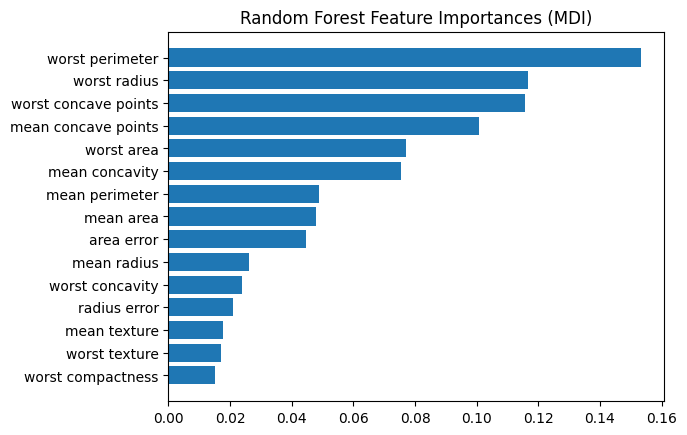

In [24]:
nbr_features = 15

tree_feature_importances = clf.feature_importances_
sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

y_ticks = np.arange(0, len(sorted_idx))
fig, ax = plt.subplots()
plt.barh(y_ticks, tree_feature_importances[sorted_idx])
plt.yticks(y_ticks, np.array(frame.feature_names)[sorted_idx])
plt.title("Random Forest Feature Importances (MDI)")
plt.show()

In [25]:
from sklearn.inspection import permutation_importance

In [26]:
result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2)

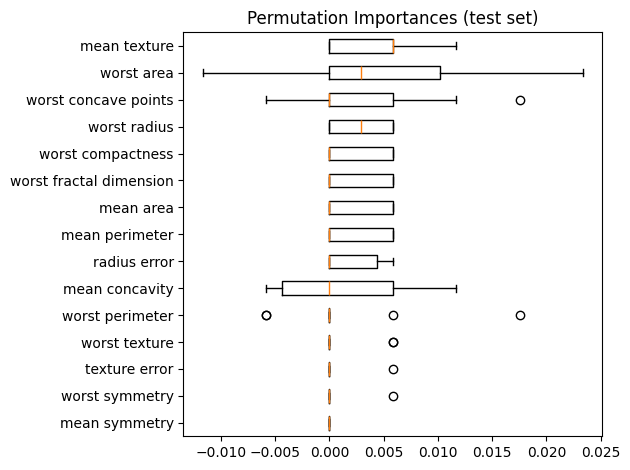

In [27]:
sorted_idx = result.importances_mean.argsort()[-nbr_features:]

fig, ax = plt.subplots()
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=np.array(frame.feature_names)[sorted_idx])
plt.title("Permutation Importances (test set)")
plt.tight_layout()
plt.show()

In [28]:
from sklearn.tree import plot_tree

In [29]:
clf.estimators_[0]

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,209652396
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


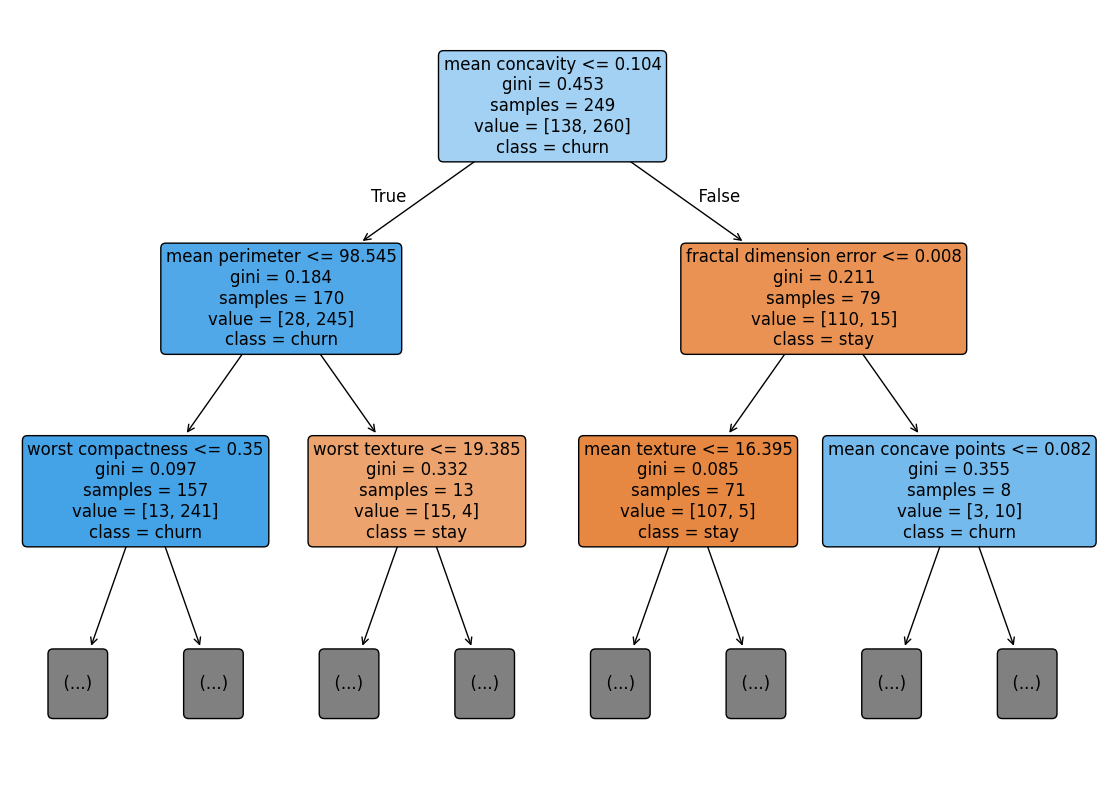

In [30]:
plt.figure(figsize=(14,10))
plot_tree(clf.estimators_[0], 
          feature_names=frame.feature_names, 
          class_names=['stay', 'churn'], 
          filled=True, 
          rounded=True,
          fontsize=12,
          max_depth=2)  
plt.show()

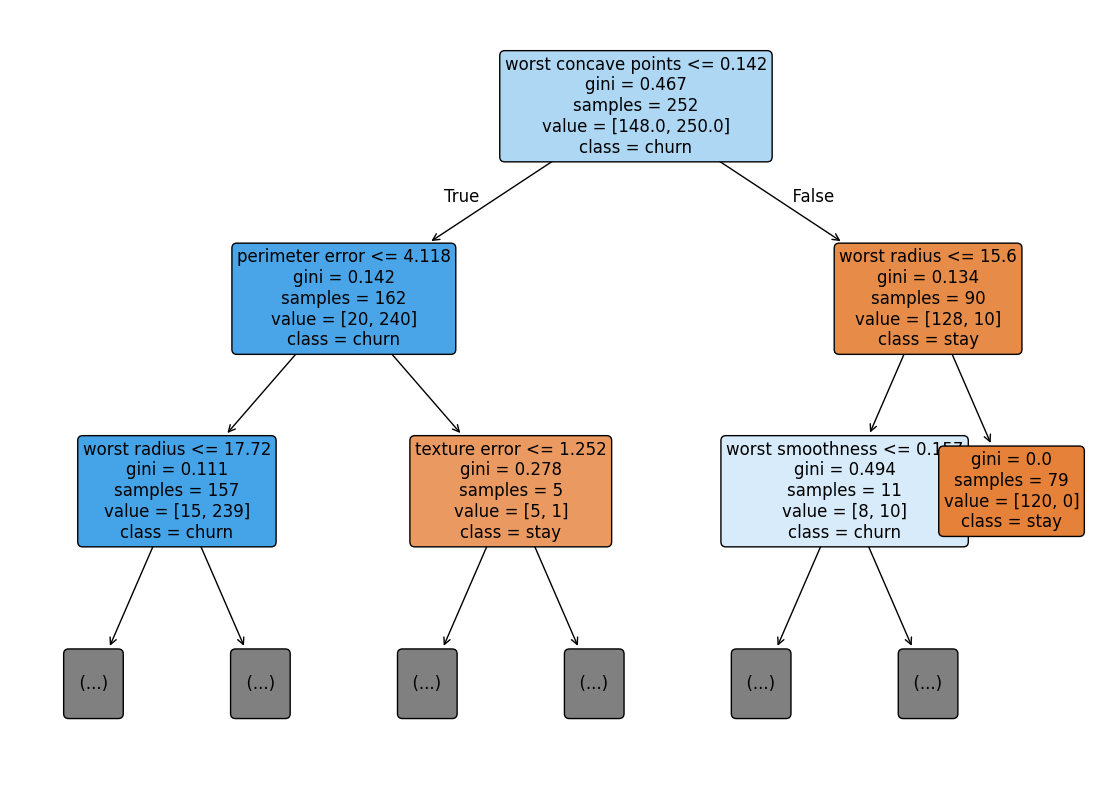

In [31]:
plt.figure(figsize=(14,10))
plot_tree(clf.estimators_[1], 
          feature_names=frame.feature_names, 
          class_names=['stay', 'churn'], 
          filled=True, 
          rounded=True,
          fontsize=12,
          max_depth=2)  
plt.show()

In [32]:
clf = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=None, min_samples_split=2, 
                             min_samples_leaf=1, 
                             min_weight_fraction_leaf=0.0, max_features=4, random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9707602339181286
F1-score [0.96124031 0.97652582]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        64
           1       0.98      0.97      0.98       107

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



In [33]:
 # importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
    
trepan_clf = TrepanClassifier(estimator = clf, s_min=1000, random_state=42)
    
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
y_pred = trepan_clf.oracle.predict(X_test)
print("Traduzione Trepan")
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Traduzione Trepan
Accuracy 0.9532163742690059
F1-score [0.93650794 0.96296296]
              precision    recall  f1-score   support

           0       0.95      0.92      0.94        64
           1       0.95      0.97      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171

Fidelity of Trepan to the original model: 0.9707602339181286


In [34]:
clf = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=None, min_samples_split=2, 
                             min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='log2', random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9707602339181286
F1-score [0.96124031 0.97652582]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        64
           1       0.98      0.97      0.98       107

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



In [35]:
 # importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
    
trepan_clf = TrepanClassifier(estimator = clf, s_min=1000, random_state=42)
    
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
y_pred = trepan_clf.oracle.predict(X_test)
print("Traduzione Trepan")
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Traduzione Trepan
Accuracy 0.9532163742690059
F1-score [0.93650794 0.96296296]
              precision    recall  f1-score   support

           0       0.95      0.92      0.94        64
           1       0.95      0.97      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171

Fidelity of Trepan to the original model: 0.9707602339181286


In [36]:
clf = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=4, min_samples_split=2, 
                             min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='log2', random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9707602339181286
F1-score [0.96062992 0.97674419]
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        64
           1       0.97      0.98      0.98       107

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



In [37]:
 # importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
    
trepan_clf = TrepanClassifier(estimator = clf, s_min=1000, random_state=42)
    
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
y_pred = trepan_clf.oracle.predict(X_test)
print("Traduzione Trepan")
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Traduzione Trepan
Accuracy 0.9532163742690059
F1-score [0.93846154 0.96226415]
              precision    recall  f1-score   support

           0       0.92      0.95      0.94        64
           1       0.97      0.95      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171

Fidelity of Trepan to the original model: 0.9824561403508771


### Cross Validation

In [38]:
from sklearn.model_selection import cross_val_score

In [39]:
clf = RandomForestClassifier()
scores = cross_val_score(clf, X, y, cv=5)

print('Accuracy %.3f +/- %.3f' % (np.mean(scores), np.std(scores)))

Accuracy 0.963 +/- 0.028


### Tuning the hyper-parameters

In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [41]:
param_list = {'min_samples_split': [2, 5, 10, 20],
              'min_samples_leaf': [1, 5, 10, 20],
             }

grid_search = GridSearchCV(clf, param_grid=param_list, cv=5)
grid_search.fit(X_train, y_train)
clf = grid_search.best_estimator_

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9707602339181286
F1-score [0.96124031 0.97652582]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        64
           1       0.98      0.97      0.98       107

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



In [42]:
param_list = {'max_depth': [None] + list(np.arange(2, 20)),
              'min_samples_split': [2, 5, 10, 20, 30, 50, 100],
              'min_samples_leaf': [1, 5, 10, 20, 30, 50, 100],
             }

random_search = RandomizedSearchCV(clf, param_distributions=param_list, n_iter=20, cv=5)
random_search.fit(X_train, y_train)
clf = random_search.best_estimator_


y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9766081871345029
F1-score [0.96875    0.98130841]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        64
           1       0.98      0.98      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



In [43]:
random_search.cv_results_['params'][random_search.cv_results_['rank_test_score'][0]]

{'min_samples_split': 30, 'min_samples_leaf': 10, 'max_depth': np.int64(13)}

In [44]:
 # importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
    
trepan_clf = TrepanClassifier(estimator = clf, s_min=1000, random_state=42)
    
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
y_pred = trepan_clf.oracle.predict(X_test)
print("Traduzione Trepan")
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Traduzione Trepan
Accuracy 0.9590643274853801
F1-score [0.944      0.96774194]
              precision    recall  f1-score   support

           0       0.97      0.92      0.94        64
           1       0.95      0.98      0.97       107

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171

Fidelity of Trepan to the original model: 0.9707602339181286


# Bagging

In [45]:
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier

If None, then the base estimator is a decision tree.

In [46]:
clf = BaggingClassifier(estimator=None, n_estimators=100, 
                        random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9649122807017544
F1-score [0.95384615 0.97169811]
              precision    recall  f1-score   support

           0       0.94      0.97      0.95        64
           1       0.98      0.96      0.97       107

    accuracy                           0.96       171
   macro avg       0.96      0.97      0.96       171
weighted avg       0.97      0.96      0.97       171



In [47]:
 # importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
    
trepan_clf = TrepanClassifier(estimator = clf, s_min=1000, random_state=42)
    
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
y_pred = trepan_clf.oracle.predict(X_test)
print("Traduzione Trepan")
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Traduzione Trepan
Accuracy 0.9415204678362573
F1-score [0.92307692 0.95283019]
              precision    recall  f1-score   support

           0       0.91      0.94      0.92        64
           1       0.96      0.94      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171

Fidelity of Trepan to the original model: 0.9766081871345029


In [48]:
clf = BaggingClassifier(estimator=SVC(C=1000), 
                        n_estimators=10, random_state=0)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9590643274853801
F1-score [0.94308943 0.96803653]
              precision    recall  f1-score   support

           0       0.98      0.91      0.94        64
           1       0.95      0.99      0.97       107

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



In [49]:
 # importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
    
trepan_clf = TrepanClassifier(estimator = clf, s_min=1000, random_state=42)
    
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
y_pred = trepan_clf.oracle.predict(X_test)
print("Traduzione Trepan")
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Traduzione Trepan
Accuracy 0.9298245614035088
F1-score [0.90163934 0.94545455]
              precision    recall  f1-score   support

           0       0.95      0.86      0.90        64
           1       0.92      0.97      0.95       107

    accuracy                           0.93       171
   macro avg       0.93      0.92      0.92       171
weighted avg       0.93      0.93      0.93       171

Fidelity of Trepan to the original model: 0.9473684210526315


In [50]:
clf = BaggingClassifier(estimator=RandomForestClassifier(n_estimators=100), n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9766081871345029
F1-score [0.96875    0.98130841]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        64
           1       0.98      0.98      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



In [51]:
 # importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
    
trepan_clf = TrepanClassifier(estimator = clf, s_min=1000, random_state=42)
    
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
y_pred = trepan_clf.oracle.predict(X_test)
print("Traduzione Trepan")
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Traduzione Trepan
Accuracy 0.9473684210526315
F1-score [0.92913386 0.95813953]
              precision    recall  f1-score   support

           0       0.94      0.92      0.93        64
           1       0.95      0.96      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171

Fidelity of Trepan to the original model: 0.9707602339181286


# Boosting

In [52]:
from sklearn.ensemble import AdaBoostClassifier

If None, then the base estimator is DecisionTreeClassifier(max_depth=1).

In [53]:
clf = AdaBoostClassifier(estimator=None, n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9766081871345029
F1-score [0.96774194 0.98165138]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        64
           1       0.96      1.00      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



In [54]:
 # importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
    
trepan_clf = TrepanClassifier(estimator = clf, s_min=1000, random_state=42)
    
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
y_pred = trepan_clf.oracle.predict(X_test)
print("Traduzione Trepan")
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Traduzione Trepan
Accuracy 0.9532163742690059
F1-score [0.93442623 0.96363636]
              precision    recall  f1-score   support

           0       0.98      0.89      0.93        64
           1       0.94      0.99      0.96       107

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171

Fidelity of Trepan to the original model: 0.9649122807017544


In [55]:
clf = AdaBoostClassifier(estimator=RandomForestClassifier(n_estimators=100), n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9824561403508771
F1-score [0.97637795 0.98604651]
              precision    recall  f1-score   support

           0       0.98      0.97      0.98        64
           1       0.98      0.99      0.99       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



In [56]:
 # importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
    
trepan_clf = TrepanClassifier(estimator = clf, s_min=1000, random_state=42)
    
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
y_pred = trepan_clf.oracle.predict(X_test)
print("Traduzione Trepan")
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Traduzione Trepan
Accuracy 0.9532163742690059
F1-score [0.93650794 0.96296296]
              precision    recall  f1-score   support

           0       0.95      0.92      0.94        64
           1       0.95      0.97      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171

Fidelity of Trepan to the original model: 0.9707602339181286
